<a href="https://colab.research.google.com/github/abhayjha800/ML_Projects/blob/main/pytorch_churnData.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import pandas as pd
import numpy as np

In [24]:
df = pd.read_csv('Churn_Modelling.csv')

In [25]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [26]:
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'],inplace=True)

In [27]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [28]:
df['Exited'].value_counts()

,count
Exited,
0,7963
1,2037


In [29]:
df['Geography'].value_counts()

,count
Geography,
France,5014
Germany,2509
Spain,2477


In [30]:
df['Gender'].value_counts()

,count
Gender,
Male,5457
Female,4543


In [31]:
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True, dtype=int)

In [32]:
df

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,0,0,1
9996,516,35,10,57369.61,1,1,1,101699.77,0,0,0,1
9997,709,36,7,0.00,1,0,1,42085.58,1,0,0,0
9998,772,42,3,75075.31,2,1,0,92888.52,1,1,0,1


In [33]:
X = df.drop(columns=['Exited'])
y = df['Exited']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [34]:
X_train.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
9254,686,32,6,0.00,2,1,1,179093.26,0,0,1
1561,632,42,4,119624.60,2,1,1,195978.86,1,0,1
1670,559,24,3,114739.92,1,1,0,85891.02,0,1,1
6087,561,27,9,135637.00,1,1,0,153080.40,0,0,0
6669,517,56,9,142147.32,1,0,0,39488.04,0,0,1


In [35]:
X_train.shape

(8000, 11)

In [36]:
y_train.head()

,Exited
9254,0
1561,0
1670,1
6087,1
6669,1


In [37]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [38]:
import torch

In [39]:
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

In [40]:
class CustomDataset(Dataset):
  def __init__(self, features, labels):
    self.features = torch.tensor(features, dtype=torch.float32)
    self.labels = torch.tensor(labels, dtype=torch.float32)


  def __len__(self):
    return len(self.labels)

  def __getitem__(self, idx):
    return self.features[idx], self.labels[idx]

In [41]:
train_dataset = CustomDataset(X_train_scaled, y_train.values)
test_dataset = CustomDataset(X_test_scaled, y_test.values)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [42]:
class ChurnModel(nn.Module):
  def __init__(self, input_dim):
    super(ChurnModel, self).__init__()
    self.network = nn.Sequential(
        nn.Linear(input_dim, 64),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(64, 32),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(32, 1),
        nn.Sigmoid()
    )

  def forward(self, x):
    return self.network(x)


In [43]:
model = ChurnModel(X_train.shape[1])

In [44]:
# !pip install torchinfo
from torchinfo import summary
import copy

In [45]:
summary(model)

Layer (type:depth-idx)                   Param #
ChurnModel                               --
├─Sequential: 1-1                        --
│    └─Linear: 2-1                       768
│    └─ReLU: 2-2                         --
│    └─Dropout: 2-3                      --
│    └─Linear: 2-4                       2,080
│    └─ReLU: 2-5                         --
│    └─Dropout: 2-6                      --
│    └─Linear: 2-7                       33
│    └─Sigmoid: 2-8                      --
Total params: 2,881
Trainable params: 2,881
Non-trainable params: 0

In [46]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [47]:
epochs = 30

In [48]:
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []


patience = 5
best_loss = float('inf')
counter = 0

best_model_wts = copy.deepcopy(model.state_dict())

for epoch in range(epochs):
  model.train()
  runningloss = 0
  correct_train = 0
  total_train = 0

  for features, labels in train_loader:
    optimizer.zero_grad()
    outputs = model(features)
    loss = criterion(outputs, labels.unsqueeze(1))
    loss.backward()
    optimizer.step()
    runningloss += loss.item()

    pred = (outputs>0.5).float()
    correct_train += (pred == labels.unsqueeze(1)).sum().item()
    total_train += labels.size(0)

  train_losses.append(runningloss / len(train_loader))
  train_accuracies.append(correct_train / total_train)

  model.eval()
  val_loss = 0
  correct_val = 0
  total_val = 0
  with torch.no_grad():
    for features, labels in test_loader:
      outputs = model(features)
      loss = criterion(outputs, labels.unsqueeze(1))
      val_loss += loss.item()


      pred = (outputs>0.5).float()
      correct_val += (pred == labels.unsqueeze(1)).sum().item()
      total_val += labels.size(0)
  val_loss /= len(test_loader)
  val_losses.append(val_loss)
  val_accuracies.append(correct_val / total_val)


  print(f"Epoch [{epoch+1}/{epochs}], Loss: {runningloss/len(train_loader):.4f}, acc: {(correct_train/total_train):.4f}, val_loss: {val_loss/len(test_loader):.4f}, val_acc: {(correct_val/total_val):.4f}")


  if val_loss < best_loss:
    best_loss = val_loss
    best_model_wts = copy.deepcopy(model.state_dict())
    torch.save(model.state_dict(), "best_model.pth")
    counter = 0
  else:
    counter +=1
    if counter >= patience:
      print(f"early stopping at epoch {epoch+1}")
      break
model.load_state_dict(best_model_wts)
print("best model loaded")


Epoch [1/30], Loss: 0.4251, acc: 0.8229, val_loss: 0.0055, val_acc: 0.8585
Epoch [2/30], Loss: 0.3753, acc: 0.8455, val_loss: 0.0056, val_acc: 0.8555
Epoch [3/30], Loss: 0.3687, acc: 0.8466, val_loss: 0.0054, val_acc: 0.8585
Epoch [4/30], Loss: 0.3665, acc: 0.8504, val_loss: 0.0054, val_acc: 0.8560
Epoch [5/30], Loss: 0.3638, acc: 0.8516, val_loss: 0.0055, val_acc: 0.8580
Epoch [6/30], Loss: 0.3580, acc: 0.8546, val_loss: 0.0054, val_acc: 0.8635
Epoch [7/30], Loss: 0.3592, acc: 0.8534, val_loss: 0.0055, val_acc: 0.8580
Epoch [8/30], Loss: 0.3541, acc: 0.8550, val_loss: 0.0054, val_acc: 0.8565
Epoch [9/30], Loss: 0.3593, acc: 0.8531, val_loss: 0.0056, val_acc: 0.8565
Epoch [10/30], Loss: 0.3518, acc: 0.8538, val_loss: 0.0054, val_acc: 0.8605
Epoch [11/30], Loss: 0.3522, acc: 0.8570, val_loss: 0.0055, val_acc: 0.8535
early stopping at epoch 11
best model loaded


In [49]:
import matplotlib.pyplot as plt

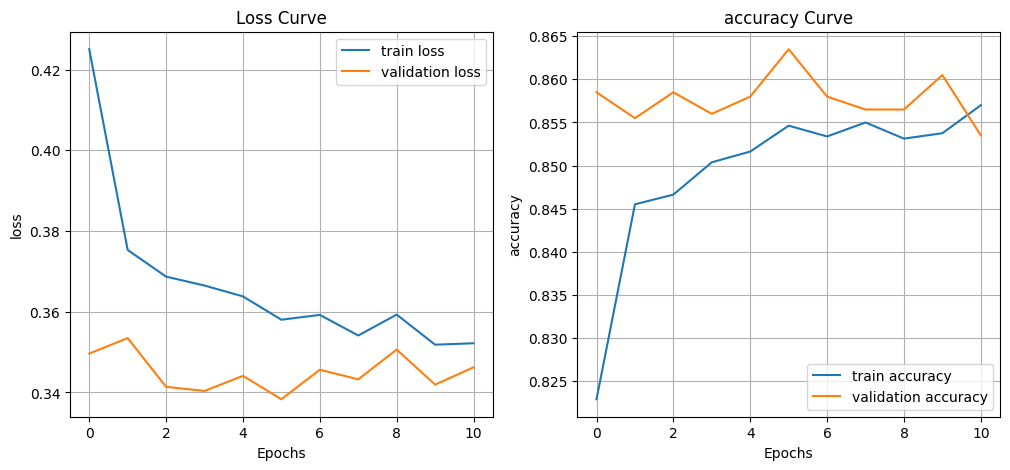

In [50]:
fig, (ax1, ax2)  = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(train_losses, label = 'train loss')
ax1.plot(val_losses, label = 'validation loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('loss')
ax1.set_title('Loss Curve')
ax1.legend()
ax1.grid(True)

ax2.plot(train_accuracies, label = 'train accuracy')
ax2.plot(val_accuracies, label = 'validation accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('accuracy')
ax2.set_title('accuracy Curve')
ax2.legend()
ax2.grid(True)

In [51]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [52]:
model.eval()
all_pred = []
all_labels = []

with torch.no_grad():
  for features, labels in test_loader:
    outputs = model(features).squeeze()
    pred = (outputs > 0.5).float()
    all_pred.extend(pred.tolist())
    all_labels.extend(labels.tolist())


print("accuracy:",accuracy_score(all_labels, all_pred))
print("confusion matrix:\n" ,confusion_matrix(all_labels, all_pred))
print("classification report:\n",classification_report(all_labels, all_pred))

accuracy: 0.8635
confusion matrix:
 [[1560   47]
 [ 226  167]]
classification report:
               precision    recall  f1-score   support

         0.0       0.87      0.97      0.92      1607
         1.0       0.78      0.42      0.55       393

    accuracy                           0.86      2000
   macro avg       0.83      0.70      0.73      2000
weighted avg       0.86      0.86      0.85      2000

